In [26]:
import pandas as pd

df = pd.read_csv('monthsales.csv')

df.head()

,Month,Sales
0,Jan-2024,120
1,Feb-2024,125
2,Mar-2024,123
3,Apr-2024,130
4,May-2024,135


In [27]:
df

,Month,Sales
0,Jan-2024,120
1,Feb-2024,125
2,Mar-2024,123
3,Apr-2024,130
4,May-2024,135
5,Jun-2024,142
6,Jul-2024,140
7,Aug-2024,148
8,Sep-2024,152
9,Oct-2024,158


In [28]:
df['Month'] = pd.to_datetime(df['Month'], format="%b-%Y")

df.set_index('Month', inplace=True)

df.head()

,Sales
Month,
2024-01-01,120
2024-02-01,125
2024-03-01,123
2024-04-01,130
2024-05-01,135


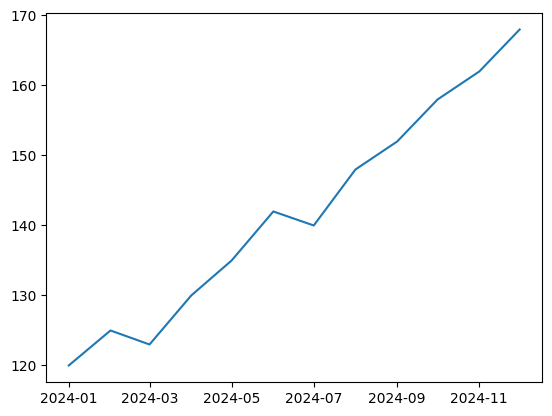

In [29]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Sales'])
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Sales'])

print(result[1])

0.9973942328792718


In [31]:
if result[1] < 0.05:
    print('Stationary')
else:
    print("Not stationary")

Not stationary


In [32]:
df['Sales_diff'] = df['Sales'].diff()

df['Sales_diff']

Month
2024-01-01    NaN
2024-02-01    5.0
2024-03-01   -2.0
2024-04-01    7.0
2024-05-01    5.0
2024-06-01    7.0
2024-07-01   -2.0
2024-08-01    8.0
2024-09-01    4.0
2024-10-01    6.0
2024-11-01    4.0
2024-12-01    6.0
Name: Sales_diff, dtype: float64

In [33]:
df_diff = df['Sales_diff'].dropna()

df_diff


Month
2024-02-01    5.0
2024-03-01   -2.0
2024-04-01    7.0
2024-05-01    5.0
2024-06-01    7.0
2024-07-01   -2.0
2024-08-01    8.0
2024-09-01    4.0
2024-10-01    6.0
2024-11-01    4.0
2024-12-01    6.0
Name: Sales_diff, dtype: float64

In [34]:
result = adfuller(df_diff)

print(result[1])

0.000551032069188067


In [35]:
if result[1] < 0.05:
    print('Stationary')
else:
    print("Not stationary")

Stationary


In [36]:
df['Rolling_Mean'] = df['Sales'].rolling(window=3).mean()
df['Rolling_Std'] = df['Sales'].rolling(window=3).std()


[]

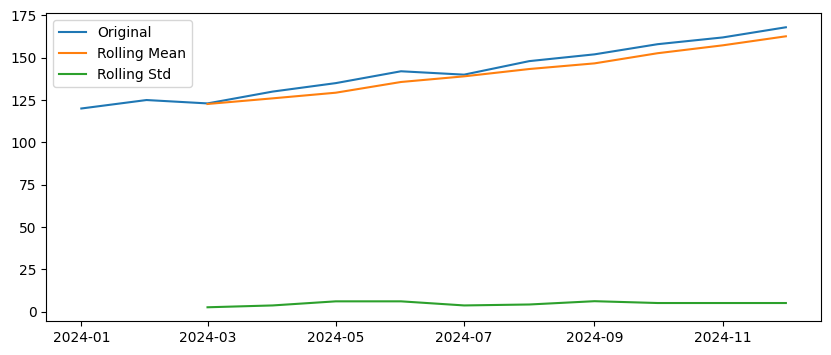

In [37]:
plt.figure(figsize=(10,4))

plt.plot(df['Sales'], label='Original')
plt.plot(df['Rolling_Mean'], label='Rolling Mean')
plt.plot(df['Rolling_Std'], label='Rolling Std')

plt.legend()
plt.plot()

In [39]:
# if varience is not constand do log transformation
import numpy as np

df['Sales_log'] = np.log(df['Sales'])

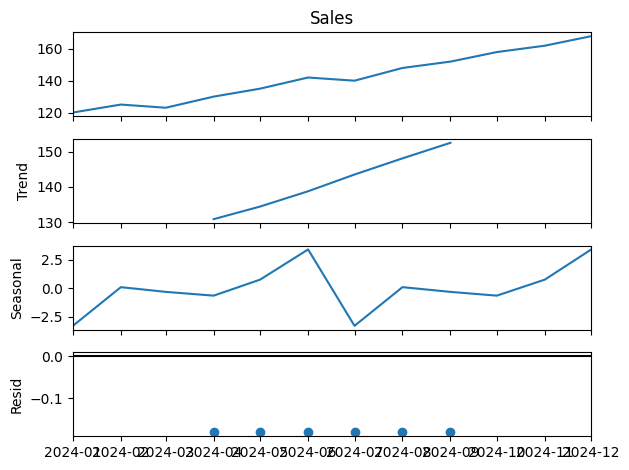

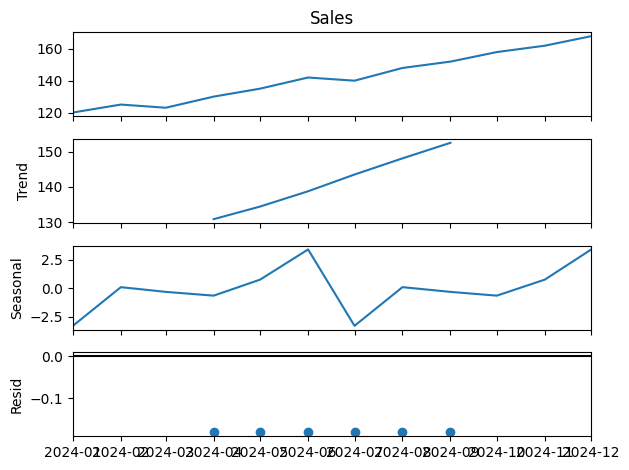

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose 

result = seasonal_decompose(
    df['Sales'],
    model='additive',
    period=6
)

result.plot()

In [40]:
df.head()

,Sales,Sales_diff,Rolling_Mean,Rolling_Std,Sales_log
Month,,,,,
2024-01-01,120,NaN,NaN,NaN,4.787492
2024-02-01,125,5.0,NaN,NaN,4.828314
2024-03-01,123,-2.0,122.666667,2.516611,4.812184
2024-04-01,130,7.0,126.000000,3.605551,4.867534
2024-05-01,135,5.0,129.333333,6.027714,4.905275
